# Check DATA_FIKS

Baca `Datalog/DATA_FIKS.xlsx` (log Misc / dashboard 15 kolom + ENU/ECEF).

In [8]:
from pathlib import Path
import pandas as pd

root = Path(r"D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01")
xlsx = root / "Datalog" / "DATA_FIKS.xlsx"

df = pd.read_excel(xlsx, sheet_name="Sheet1")
print(xlsx)
print("baris, kolom:", df.shape)
print("kolom:", list(df.columns))
df.head()

D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01\Datalog\DATA_FIKS.xlsx
baris, kolom: (382, 24)
kolom: ['timestamp', 'latitude', 'longitude', 'speedMps', 'Calc_deg_servo_1', 'Calc_deg_servo_2', 'roll', 'pitch', 'yaw', 'zigzag_yaw', 'rpm_prop_1', 'rpm_prop_2', 'battery_1', 'battery_2', 'mode_auto', 'x_enu_flat', 'y_enu_flat', 'z_enu_flat', 'X_ecef', 'Y_ecef', 'Z_ecef', 'x_enu_ecef', 'y_enu_ecef', 'z_enu_ecef']


,timestamp,latitude,longitude,speedMps,Calc_deg_servo_1,Calc_deg_servo_2,roll,pitch,yaw,zigzag_yaw,...,mode_auto,x_enu_flat,y_enu_flat,z_enu_flat,X_ecef,Y_ecef,Z_ecef,x_enu_ecef,y_enu_ecef,z_enu_ecef
0,1993.731,-7.287184,112.796194,0.15,-40.00,-39.93,5.13,0.18,324.99,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
1,1993.831,-7.287184,112.796194,0.20,-40.06,-40.11,5.14,0.18,324.87,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
2,1993.931,-7.287184,112.796194,0.13,-40.41,-40.17,5.15,0.19,324.78,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
3,1994.031,-7.287184,112.796194,0.16,-39.94,-39.87,5.15,0.21,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
4,1994.131,-7.287184,112.796194,0.18,-40.24,-40.47,5.15,0.24,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0


In [9]:
df.info()
df[["timestamp", "latitude", "longitude", "speedMps", "yaw", "mode_auto"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         382 non-null    float64
 1   latitude          382 non-null    float64
 2   longitude         382 non-null    float64
 3   speedMps          382 non-null    float64
 4   Calc_deg_servo_1  382 non-null    float64
 5   Calc_deg_servo_2  382 non-null    float64
 6   roll              382 non-null    float64
 7   pitch             382 non-null    float64
 8   yaw               382 non-null    float64
 9   zigzag_yaw        382 non-null    int64  
 10  rpm_prop_1        382 non-null    int64  
 11  rpm_prop_2        382 non-null    int64  
 12  battery_1         382 non-null    float64
 13  battery_2         382 non-null    float64
 14  mode_auto         382 non-null    int64  
 15  x_enu_flat        382 non-null    float64
 16  y_enu_flat        382 non-null    float64
 1

,timestamp,latitude,longitude,speedMps,yaw,mode_auto
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,2012.887283,-7.287173,112.796127,0.611440,160.963063,0.727749
std,11.160892,0.000013,0.000032,0.140706,131.267766,0.445702
min,1993.731000,-7.287188,112.796088,0.130000,0.020000,0.000000
25%,2003.256000,-7.287183,112.796102,0.550000,20.520000,0.000000
50%,2012.781000,-7.287178,112.796120,0.610000,142.195000,1.000000
75%,2022.606000,-7.287163,112.796150,0.700000,304.400000,1.000000
max,2032.131000,-7.287147,112.796194,0.920000,359.100000,1.000000


Yaw di file ini sudah 0–360 (bukan −180…180). Konvensi HWT905 setelah wrap Remote/Send: **0 = Utara, 270 ≈ Timur, 90 ≈ Barat**.

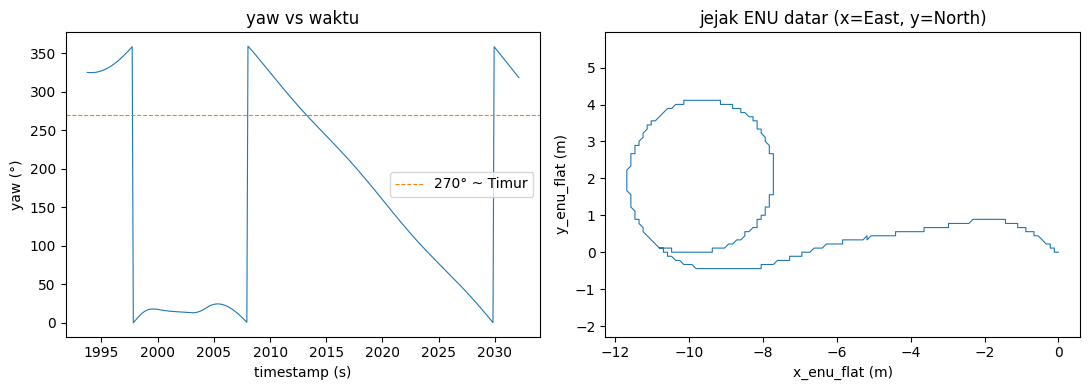

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["timestamp"], df["yaw"], lw=0.8)
ax[0].set_title("yaw vs waktu")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("yaw (°)")
ax[0].axhline(270, color="C1", ls="--", lw=0.8, label="270° ~ Timur")
ax[0].legend()

ax[1].plot(df["x_enu_flat"], df["y_enu_flat"], lw=0.8)
ax[1].set_title("jejak ENU datar (x=East, y=North)")
ax[1].set_xlabel("x_enu_flat (m)")
ax[1].set_ylabel("y_enu_flat (m)")
ax[1].axis("equal")
fig.tight_layout()
plt.show()

Bandingkan ENU datar rumus 1.2 / Remote (`R = 6 371 000` m) dengan kolom `x_enu_flat`, `y_enu_flat`.

Origin = baris pertama file: **lat0 = −7.287184**, **lon0 = 112.796194**.

```text
x = (lon − lon0) × (π/180) × R × cos(lat0)   // East
y = (lat − lat0) × (π/180) × R                 // North
```

origin lat0=-7.287184  lon0=112.796194
RMSE x  0.000000 m   max |dx| 0.000000 m
RMSE y  0.000000 m   max |dy| 0.000000 m


,timestamp,latitude,longitude,x_calc,x_enu_flat,dx_enu,y_calc,y_enu_flat,dy_enu
0,1993.731,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,1993.831,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
2,1993.931,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
3,1994.031,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
4,1994.131,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
5,1994.231,-7.287184,112.796193,-0.110297,-0.110297,1.387779e-17,0.000000,0.000000,0.000000e+00
6,1994.331,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16
7,1994.431,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16


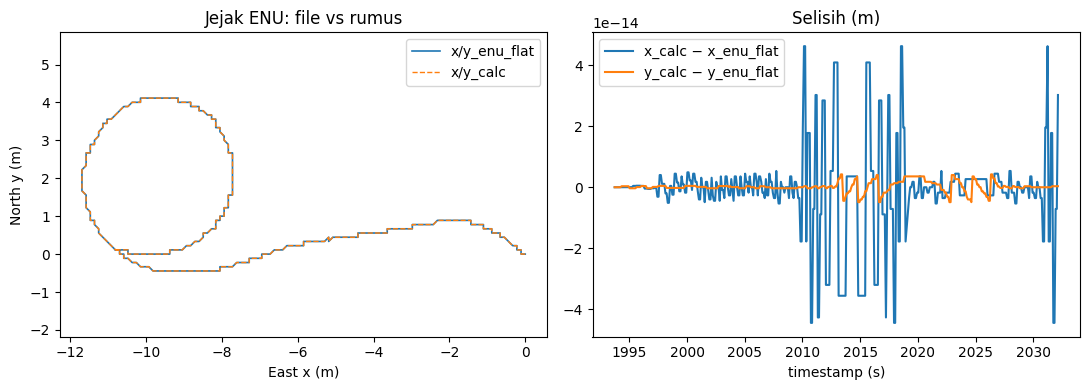

In [11]:
import numpy as np

R = 6_371_000.0
lat0 = float(df.iloc[0]["latitude"])   # -7.287184
lon0 = float(df.iloc[0]["longitude"])  # 112.796194
lat0_rad = np.deg2rad(lat0)

df["x_calc"] = np.deg2rad(df["longitude"] - lon0) * R * np.cos(lat0_rad)
df["y_calc"] = np.deg2rad(df["latitude"] - lat0) * R
df["dx_enu"] = df["x_calc"] - df["x_enu_flat"]
df["dy_enu"] = df["y_calc"] - df["y_enu_flat"]

print(f"origin lat0={lat0:.6f}  lon0={lon0:.6f}")
print(f"RMSE x  {np.sqrt(np.mean(df['dx_enu']**2)):.6f} m   max |dx| {df['dx_enu'].abs().max():.6f} m")
print(f"RMSE y  {np.sqrt(np.mean(df['dy_enu']**2)):.6f} m   max |dy| {df['dy_enu'].abs().max():.6f} m")

display(df[["timestamp", "latitude", "longitude", "x_calc", "x_enu_flat", "dx_enu", "y_calc", "y_enu_flat", "dy_enu"]].head(8))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["x_enu_flat"], df["y_enu_flat"], label="x/y_enu_flat", lw=1.2)
ax[0].plot(df["x_calc"], df["y_calc"], "--", label="x/y_calc", lw=1.0)
ax[0].set_title("Jejak ENU: file vs rumus")
ax[0].set_xlabel("East x (m)")
ax[0].set_ylabel("North y (m)")
ax[0].axis("equal")
ax[0].legend()

ax[1].plot(df["timestamp"], df["dx_enu"], label="x_calc − x_enu_flat")
ax[1].plot(df["timestamp"], df["dy_enu"], label="y_calc − y_enu_flat")
ax[1].set_title("Selisih (m)")
ax[1].set_xlabel("timestamp (s)")
ax[1].legend()
fig.tight_layout()
plt.show()

Langkah 2 — kecepatan peta dari Δposisi (sama 1.2, α = 0.70).

```text
Δt = timestamp_k − timestamp_{k-1}
ẋ_raw = (x_k − x_{k-1}) / Δt
ẏ_raw = (y_k − y_{k-1}) / Δt
ẋ = 0.70 · ẋ_lama + 0.30 · ẋ_raw
ẏ = 0.70 · ẏ_lama + 0.30 · ẏ_raw
|V| = √(ẋ² + ẏ²)
```

`ẋ > 0` ke timur, `ẏ > 0` ke utara. Yaw IMU: **0 ~ Utara**, **270 ~ Timur** (bukan 90 = Timur).

sampel vel_ok=381 / 382  α=0.7
ẋ  mean=-0.283  min=-0.984  max=0.785 m/s  (+ = timur)
ẏ  mean=0.001  min=-0.785  max=0.819 m/s  (+ = utara)
|V| mean=0.633  speedMps mean=0.613 m/s


,timestamp,x_enu_flat,y_enu_flat,x_dot,y_dot,V_enu,speedMps,yaw
0,1993.731,0.000000,0.000000,0.000000,0.000000,0.000000,0.15,324.99
1,1993.831,0.000000,0.000000,0.000000,0.000000,0.000000,0.20,324.87
2,1993.931,0.000000,0.000000,0.000000,0.000000,0.000000,0.13,324.78
3,1994.031,0.000000,0.000000,0.000000,0.000000,0.000000,0.16,324.73
4,1994.131,0.000000,0.000000,0.000000,0.000000,0.000000,0.18,324.73
5,1994.231,-0.110297,0.000000,-0.330890,0.000000,0.330890,0.19,324.78
6,1994.331,-0.110297,0.111195,-0.231623,0.333585,0.406113,0.18,324.89
7,1994.431,-0.110297,0.111195,-0.162136,0.233509,0.284279,0.18,325.06


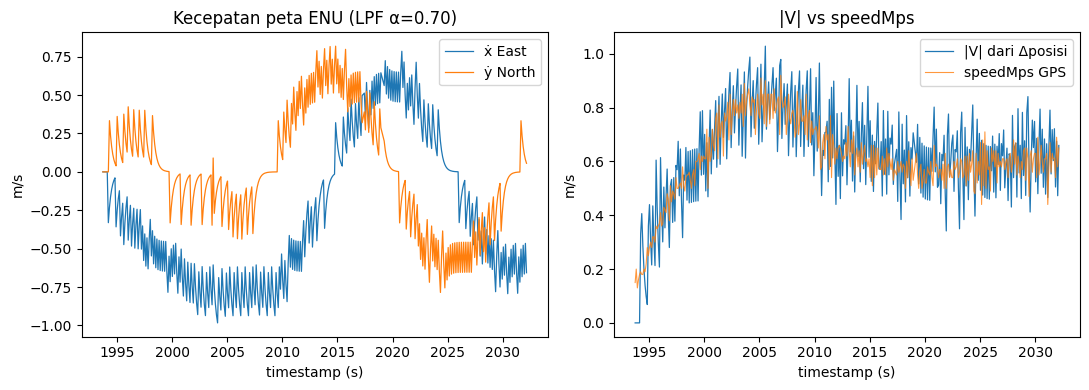

In [12]:
alpha = 0.70
min_dt, max_dt = 0.001, 1.0

x = df["x_calc"] if "x_calc" in df.columns else df["x_enu_flat"]
y = df["y_calc"] if "y_calc" in df.columns else df["y_enu_flat"]
t = df["timestamp"].to_numpy()

n = len(df)
x_dot = np.zeros(n)
y_dot = np.zeros(n)
speed_v = np.zeros(n)
vel_ok = np.zeros(n, dtype=bool)

for k in range(1, n):
    dt = t[k] - t[k - 1]
    if dt < min_dt or dt > max_dt:
        x_dot[k] = 0.0
        y_dot[k] = 0.0
        continue
    x_raw = (x.iloc[k] - x.iloc[k - 1]) / dt
    y_raw = (y.iloc[k] - y.iloc[k - 1]) / dt
    x_dot[k] = alpha * x_dot[k - 1] + (1.0 - alpha) * x_raw
    y_dot[k] = alpha * y_dot[k - 1] + (1.0 - alpha) * y_raw
    speed_v[k] = np.hypot(x_dot[k], y_dot[k])
    vel_ok[k] = True

df["x_dot"] = x_dot
df["y_dot"] = y_dot
df["V_enu"] = speed_v
df["dV_speed"] = df["V_enu"] - df["speedMps"]

ok = vel_ok
v_ok = df.loc[ok, "V_enu"]
s_ok = df.loc[ok, "speedMps"]
d_ok = df.loc[ok, "dV_speed"]
rmse = float(np.sqrt(np.mean(d_ok**2)))
mae = float(np.mean(np.abs(d_ok)))
corr = float(np.corrcoef(v_ok, s_ok)[0, 1]) if len(v_ok) > 1 else float("nan")

print(f"sampel vel_ok={ok.sum()} / {n}  α={alpha}")
print(f"ẋ  mean={x_dot[ok].mean():.3f}  min={x_dot[ok].min():.3f}  max={x_dot[ok].max():.3f} m/s  (+ = timur)")
print(f"ẏ  mean={y_dot[ok].mean():.3f}  min={y_dot[ok].min():.3f}  max={y_dot[ok].max():.3f} m/s  (+ = utara)")
print("--- banding |V| vs speedMps ---")
print(f"|V|      mean={v_ok.mean():.3f}  min={v_ok.min():.3f}  max={v_ok.max():.3f} m/s")
print(f"speedMps mean={s_ok.mean():.3f}  min={s_ok.min():.3f}  max={s_ok.max():.3f} m/s")
print(f"|V|-speedMps  RMSE={rmse:.3f}  MAE={mae:.3f}  max|d|={d_ok.abs().max():.3f}  corr={corr:.3f}")

display(df[["timestamp", "x_dot", "y_dot", "V_enu", "speedMps", "dV_speed", "yaw"]].head(8))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(df["timestamp"], df["x_dot"], label="ẋ East", lw=0.9)
ax[0].plot(df["timestamp"], df["y_dot"], label="ẏ North", lw=0.9)
ax[0].set_title("Kecepatan peta ENU (LPF α=0.70)")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("m/s")
ax[0].legend()

ax[1].plot(df["timestamp"], df["V_enu"], label="|V| Δposisi", lw=0.9)
ax[1].plot(df["timestamp"], df["speedMps"], label="speedMps GPS", lw=0.8, alpha=0.8)
ax[1].set_title("|V| vs speedMps")
ax[1].set_xlabel("timestamp (s)")
ax[1].set_ylabel("m/s")
ax[1].legend()

lim = [0, max(v_ok.max(), s_ok.max()) * 1.05]
ax[2].scatter(s_ok, v_ok, s=8, alpha=0.5)
ax[2].plot(lim, lim, "k--", lw=0.8, label="y = x")
ax[2].set_title(f"sebaran (RMSE={rmse:.3f} m/s)")
ax[2].set_xlabel("speedMps (m/s)")
ax[2].set_ylabel("|V| (m/s)")
ax[2].set_aspect("equal", adjustable="box")
ax[2].legend()
fig.tight_layout()
plt.show()